# Загрузка датасета и импорты

In [49]:
from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

from sklearn.model_selection import StratifiedKFold, cross_val_score,cross_val_predict, GridSearchCV
from sklearn.metrics import roc_auc_score, make_scorer

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [2]:
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")

# Переменные окружения и настройки

In [217]:
pd.set_option('display.max_columns', None)

plt.rcParams['figure.figsize'] = (10,5)

In [12]:
SEED=42

## EDA

## Знакомство с данными

In [219]:
train.shape

(595212, 59)

In [220]:
train.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10,1,-1,0,1,4,1,0,0,1,12,2,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11,1,-1,0,-1,11,1,1,2,1,19,3,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.000000,7,1,-1,0,-1,14,1,1,2,1,60,1,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.2,0.580948,7,1,0,0,1,11,1,1,3,1,104,1,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2,4,7,1,8,4,2,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,9,1,0,0,0.7,0.6,0.840759,11,1,-1,0,-1,14,1,1,2,1,82,3,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2,2,6,3,10,2,12,3,1,1,3,0,0,0,1,1,0


In [221]:
train.sample(10, random_state=SEED)

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
256886,642026,0,4,1,5,1,0,1,0,0,0,0,0,0,0,0,8,0,1,0,0.7,1.4,1.368393,10,1,-1,0,1,11,1,1,0,1,16,3,0.421782,0.596720,0.373497,1.414214,0.0,0.3,0.2,5,0,8,3,9,3,7,7,3,2,3,0,1,0,1,0,0
118785,297043,0,6,2,10,1,0,0,0,0,1,0,0,0,0,0,5,1,0,0,0.9,1.4,1.798437,10,0,-1,0,1,5,1,1,0,1,104,1,0.424264,1.237825,0.446094,3.162278,0.3,0.8,0.3,1,1,8,4,8,4,9,6,3,3,5,0,1,1,0,0,0
56083,140591,0,4,1,9,1,0,0,0,1,0,0,0,0,0,0,10,0,0,0,0.1,0.1,-1.000000,11,1,0,0,1,1,1,1,1,1,31,3,0.400000,0.546628,-1.000000,1.000000,0.2,0.6,0.3,5,1,8,2,8,2,12,3,1,0,7,0,0,1,0,0,0
542002,1354540,0,0,1,7,1,4,0,1,0,0,0,0,0,0,0,3,0,0,1,0.9,1.3,0.868907,11,1,1,0,1,15,1,0,2,1,97,3,0.360555,0.874147,0.298329,3.605551,0.4,0.8,0.1,3,2,7,4,10,2,5,1,1,3,6,1,1,0,0,0,0
349518,873173,0,1,1,3,1,0,1,0,0,0,0,0,0,0,0,12,0,1,0,0.6,0.4,0.741620,11,1,-1,0,-1,1,1,1,2,1,38,3,0.316228,0.740165,0.359861,3.464102,0.0,0.8,0.9,3,2,10,3,11,3,10,6,1,5,6,0,1,0,0,0,0
328884,821910,0,0,2,1,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.1,0.3,-1.000000,5,1,0,0,0,6,1,1,0,1,26,3,0.400000,0.630001,0.320468,2.645751,0.2,0.9,0.9,1,3,10,3,10,2,9,5,2,2,10,0,0,1,0,1,0
175820,439409,0,4,1,4,1,0,0,1,0,0,0,0,0,0,0,10,0,0,0,0.7,0.2,0.517204,7,1,0,0,0,0,1,1,2,1,22,3,0.316228,0.808980,0.310322,3.464102,0.7,0.0,0.5,5,1,6,3,10,7,10,3,2,9,9,0,0,1,0,0,0
30874,77431,0,0,1,4,0,0,1,0,0,0,0,0,0,0,0,4,1,0,0,0.2,0.2,-1.000000,11,1,0,1,1,16,1,1,2,1,104,2,0.400000,0.906143,0.388587,3.162278,0.5,0.6,0.2,2,3,9,1,11,3,6,10,1,3,6,0,1,1,0,0,0
367208,917681,0,4,2,2,0,0,0,0,0,1,0,0,0,0,0,2,0,0,1,0.8,1.2,1.327356,4,1,-1,0,0,1,1,1,0,1,70,3,0.374166,0.764231,0.393700,3.162278,0.9,0.1,0.8,3,2,9,6,11,1,9,5,2,4,6,0,0,1,0,1,0
276018,689844,0,1,1,3,0,3,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.3,0.814709,11,1,-1,0,-1,0,1,1,1,1,22,3,0.316228,0.784298,0.374566,3.464102,0.3,0.8,0.0,2,2,5,4,8,0,10,7,1,2,6,1,0,1,0,0,0


In [222]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_bin   59521

In [223]:
train.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,0.185304,0.000373,0.001692,0.009439,0.000948,0.012451,7.299922,0.660823,0.121081,0.153446,0.610991,0.439184,0.551102,8.295933,0.829931,-0.504899,0.725192,-0.157732,6.555340,0.910027,0.832080,1.328890,0.992136,62.215674,2.346072,0.379945,0.813265,0.276256,3.065899,0.449756,0.449589,0.449849,2.372081,1.885886,7.689445,3.005823,9.225904,2.339034,8.433590,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,0.388544,0.019309,0.041097,0.096693,0.030768,0.127545,3.546042,0.473430,0.326222,0.360417,0.287643,0.404264,0.793506,2.508270,0.375716,0.788654,2.153463,0.844417,5.501445,0.347106,0.373796,0.978747,0.091619,33.012455,0.832548,0.058327,0.224588,0.357154,0.731366,0.287198,0.286893,0.287153,1.117219,1.134927,1.334312,1.414564,1.459672,1.246949,2.904597,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,1.000000,-1.000000,-1.000000,0.250619,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.400000,0.200000,0.525000,7.000000,1.000000,-1.000000,0.000000,-1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,32.000000,2.000000,0.316228,0.670867,0.333167,2.828427,0.200000,0.200000,0.200000,2.000000,1.000000,7.000000,2.000000,8.000000,1.000000,6.000000,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,1.000000,0.000000,0.000000,0.700000,0.300000,0.720677,7.000000,1.000000,-1.000000,0.000000,0.000000,7.0000

Замечаем по таргету, что есть явный дисбаланс классов по `target`.

In [224]:
train.isnull().sum()

id                0
target            0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0


In [225]:
test.isnull().sum()

id                0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0
ps_calc_12        0


Пропусков совсем нет.
Было бы приятно, но после этого наблюдения нашёл в описании, что пропуски заполнены `-1`.

In [226]:
(train == -1).sum()

id                     0
target                 0
ps_ind_01              0
ps_ind_02_cat        216
ps_ind_03              0
ps_ind_04_cat         83
ps_ind_05_cat       5809
ps_ind_06_bin          0
ps_ind_07_bin          0
ps_ind_08_bin          0
ps_ind_09_bin          0
ps_ind_10_bin          0
ps_ind_11_bin          0
ps_ind_12_bin          0
ps_ind_13_bin          0
ps_ind_14              0
ps_ind_15              0
ps_ind_16_bin          0
ps_ind_17_bin          0
ps_ind_18_bin          0
ps_reg_01              0
ps_reg_02              0
ps_reg_03         107772
ps_car_01_cat        107
ps_car_02_cat          5
ps_car_03_cat     411231
ps_car_04_cat          0
ps_car_05_cat     266551
ps_car_06_cat          0
ps_car_07_cat      11489
ps_car_08_cat          0
ps_car_09_cat        569
ps_car_10_cat          0
ps_car_11_cat          0
ps_car_11              5
ps_car_12              1
ps_car_13              0
ps_car_14          42620
ps_car_15              0
ps_calc_01             0


In [227]:
(test == -1).sum()

id                     0
ps_ind_01              0
ps_ind_02_cat        307
ps_ind_03              0
ps_ind_04_cat        145
ps_ind_05_cat       8710
ps_ind_06_bin          0
ps_ind_07_bin          0
ps_ind_08_bin          0
ps_ind_09_bin          0
ps_ind_10_bin          0
ps_ind_11_bin          0
ps_ind_12_bin          0
ps_ind_13_bin          0
ps_ind_14              0
ps_ind_15              0
ps_ind_16_bin          0
ps_ind_17_bin          0
ps_ind_18_bin          0
ps_reg_01              0
ps_reg_02              0
ps_reg_03         161684
ps_car_01_cat        160
ps_car_02_cat          5
ps_car_03_cat     616911
ps_car_04_cat          0
ps_car_05_cat     400359
ps_car_06_cat          0
ps_car_07_cat      17331
ps_car_08_cat          0
ps_car_09_cat        877
ps_car_10_cat          0
ps_car_11_cat          0
ps_car_11              1
ps_car_12              0
ps_car_13              0
ps_car_14          63805
ps_car_15              0
ps_calc_01             0
ps_calc_02             0


Всё-таки есть. Неприятно.

In [228]:
for column in train.columns:
    print(f"{column}:{train[column].unique().size}")

id:595212
target:2
ps_ind_01:8
ps_ind_02_cat:5
ps_ind_03:12
ps_ind_04_cat:3
ps_ind_05_cat:8
ps_ind_06_bin:2
ps_ind_07_bin:2
ps_ind_08_bin:2
ps_ind_09_bin:2
ps_ind_10_bin:2
ps_ind_11_bin:2
ps_ind_12_bin:2
ps_ind_13_bin:2
ps_ind_14:5
ps_ind_15:14
ps_ind_16_bin:2
ps_ind_17_bin:2
ps_ind_18_bin:2
ps_reg_01:10
ps_reg_02:19
ps_reg_03:5013
ps_car_01_cat:13
ps_car_02_cat:3
ps_car_03_cat:3
ps_car_04_cat:10
ps_car_05_cat:3
ps_car_06_cat:18
ps_car_07_cat:3
ps_car_08_cat:2
ps_car_09_cat:6
ps_car_10_cat:3
ps_car_11_cat:104
ps_car_11:5
ps_car_12:184
ps_car_13:70482
ps_car_14:850
ps_car_15:15
ps_calc_01:10
ps_calc_02:10
ps_calc_03:10
ps_calc_04:6
ps_calc_05:7
ps_calc_06:11
ps_calc_07:10
ps_calc_08:11
ps_calc_09:8
ps_calc_10:26
ps_calc_11:20
ps_calc_12:11
ps_calc_13:14
ps_calc_14:24
ps_calc_15_bin:2
ps_calc_16_bin:2
ps_calc_17_bin:2
ps_calc_18_bin:2
ps_calc_19_bin:2
ps_calc_20_bin:2


В названии столбцов содержится смысл данных:
* ps_ind_ - индивидуальные характеристики человека
* ps_car_ - характеристика автомобиля
* ps_reg_ - региональные характеристики
* ps_calc_ - рассчитанные признаки

А так же тип признака в суффиксе:
* \_bin - бинарный признак
* \_cat - категориальный
* без суффикса - числовой непрерывный или порядковый

## Анализ целевой переменной

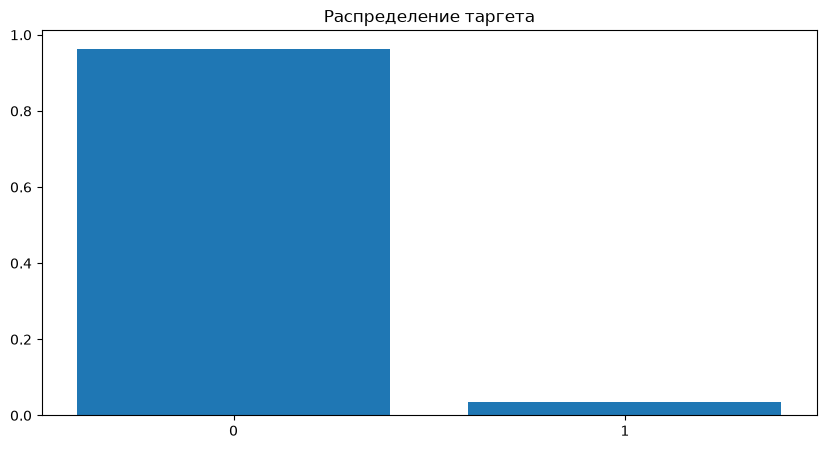

In [229]:
target_counts = train["target"].value_counts(normalize=True)
fig_1, ax_1 = plt.subplots()

ax_1.bar(target_counts.index, target_counts)
ax_1.set_title("Распределение таргета")
ax_1.set_xticks(target_counts.index)
ax_1.set_xticklabels(target_counts.index)

plt.show()

Утверждаем предположение о сильном дисбалансе. Необходимо использовать стратификацию.


В качестве метрики соревнования указан Normalized Gini Coefficient. Он уместен при дисбалансе.

## Анализ пропусков

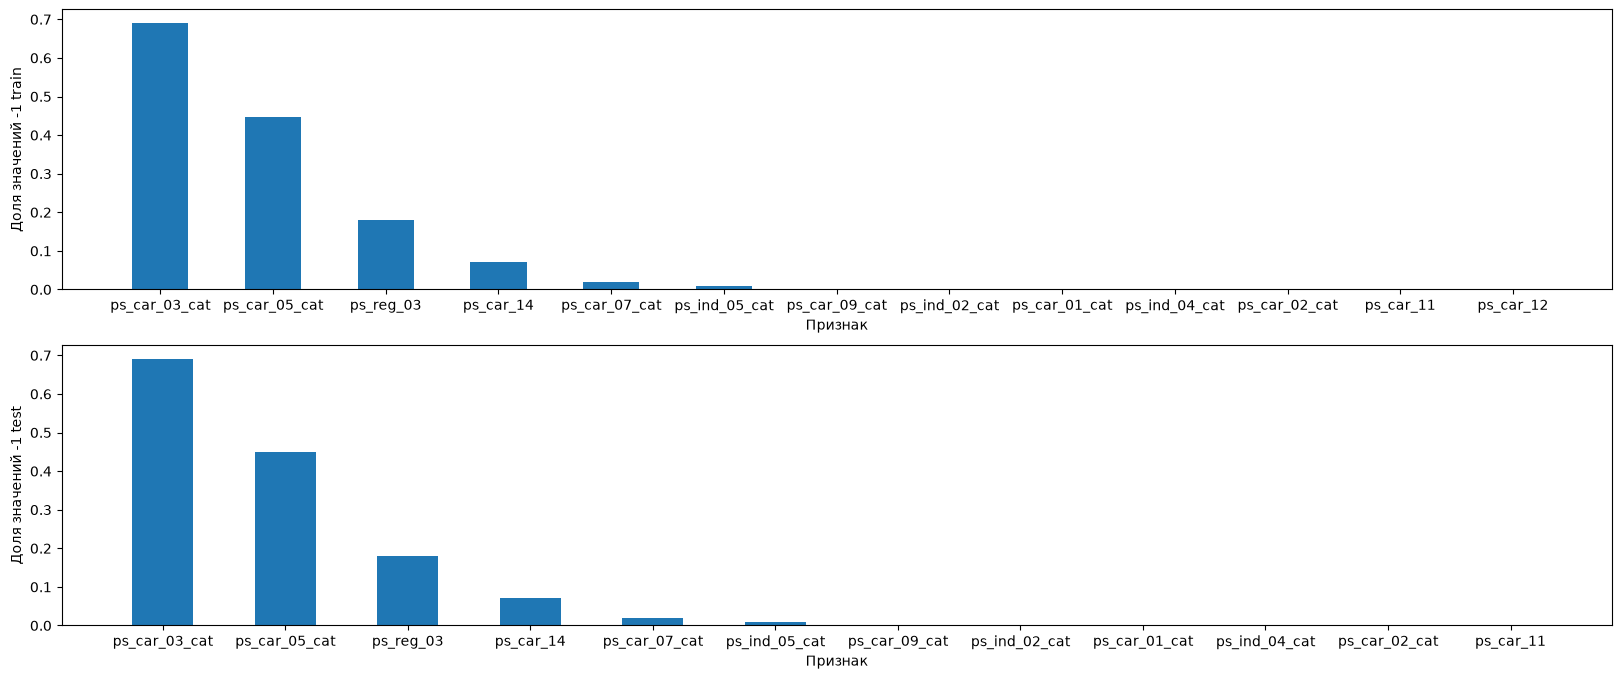

In [230]:
missings_train = (train == -1).mean()
top_missings_train = missings_train[missings_train > 0].sort_values(ascending=False)

missings_test = (test == -1).mean()
top_missings_test = missings_test[missings_test > 0].sort_values(ascending=False)

fig_2,ax_2 = plt.subplots(2,1,figsize=(20,8))
ax_2[0].bar(top_missings_train.index, top_missings_train, width=0.5)
ax_2[1].bar(top_missings_test.index, top_missings_test, width=0.5)

ax_2[0].set_ylabel("Доля значений -1 train")
ax_2[0].set_xlabel("Признак")

ax_2[1].set_ylabel("Доля значений -1 test")
ax_2[1].set_xlabel("Признак")
plt.show()

In [231]:
missings = pd.DataFrame({
    'train': top_missings_train,
    'test': top_missings_test,
})

missings = missings.sort_values(by='train', ascending=False)

display(missings)

,train,test
ps_car_03_cat,0.690898,0.690972
ps_car_05_cat,0.447825,0.448423
ps_reg_03,0.181065,0.181094
ps_car_14,0.071605,0.071465
ps_car_07_cat,0.019302,0.019412
ps_ind_05_cat,0.009760,0.009756
ps_car_09_cat,0.000956,0.000982
ps_ind_02_cat,0.000363,0.000344
ps_car_01_cat,0.000180,0.000179
ps_ind_04_cat,0.000139,0.000162


Доли пропущенных значений в train и test почти одинаковые.

## Анализ признаков

### Heat map по бинарным и числовым признакам

In [3]:
bin_features = [c for c in train.columns if c.endswith('_bin')]
cat_features = [c for c in train.columns if c.endswith('_cat')]
num_features = [c for c in train.columns if not(c.endswith('_bin')) and not(c.endswith('_cat')) and c not in ['id', 'target']]

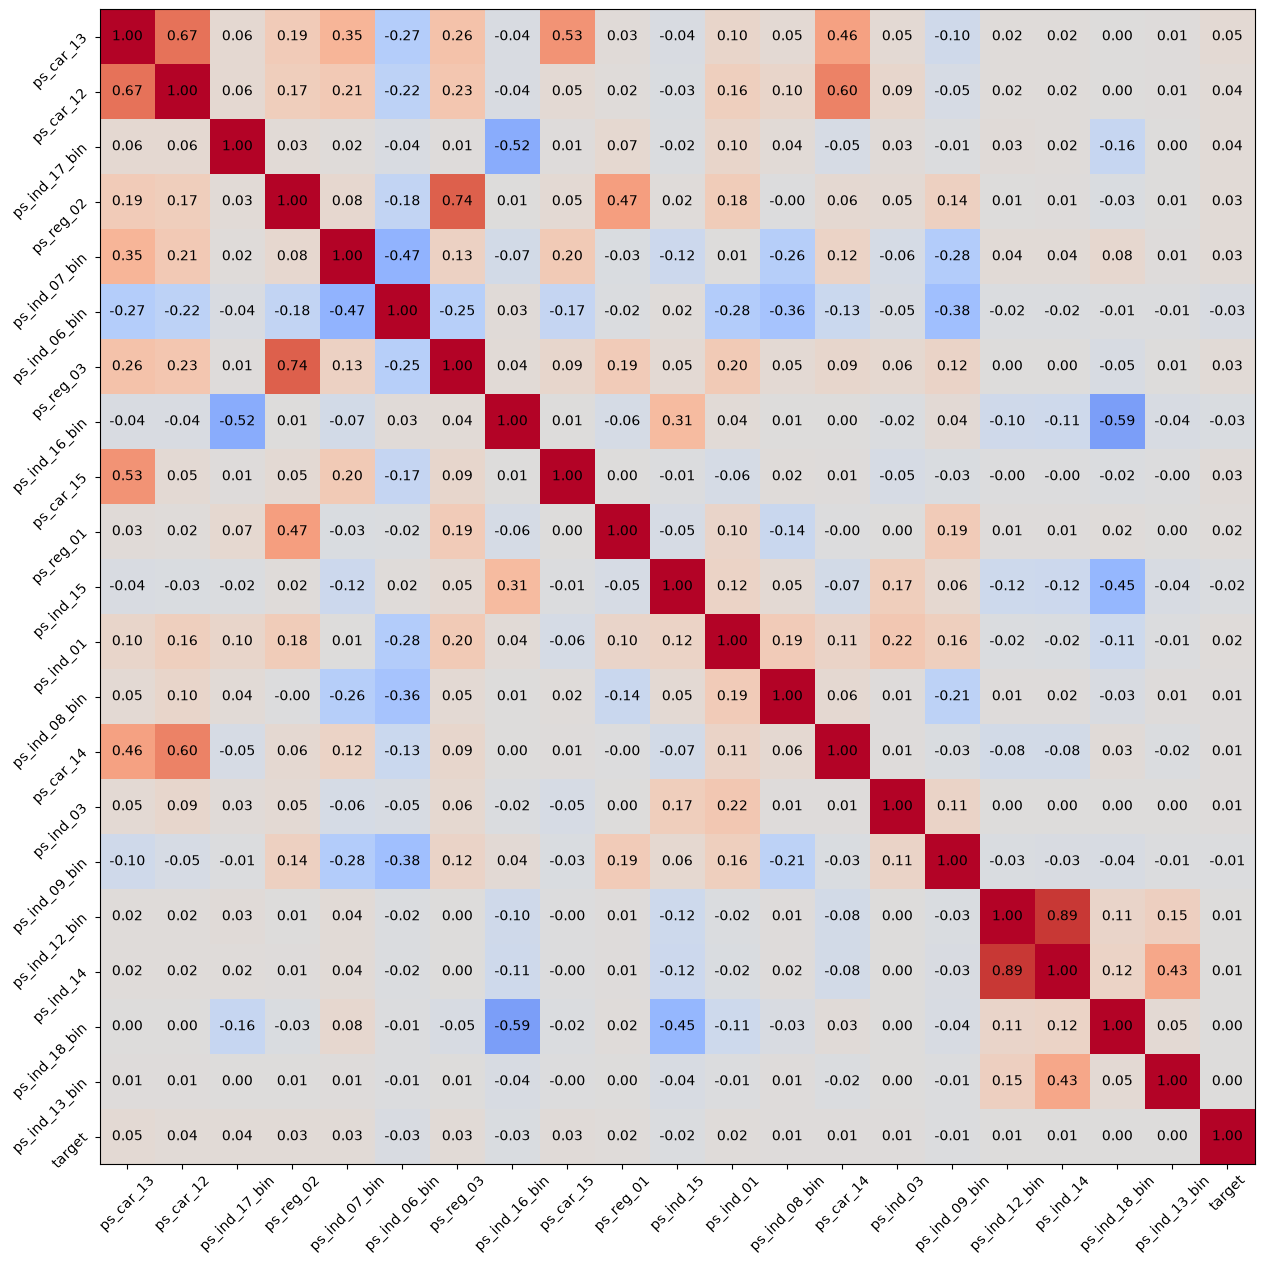

In [233]:
train["target"] = train.pop("target")
corr_features = num_features + bin_features + ['target']
corr_matrix = train[corr_features].replace(-1, np.nan).corr()

top_features = (
    corr_matrix['target']
    .drop('target')
    .abs()
    .nlargest(20)
    .index
    .tolist()
)
selected_features = top_features + ['target']

corr_matrix = corr_matrix.loc[selected_features, selected_features]

fig_3, ax_3 = plt.subplots(figsize=(15,15))

image = ax_3.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap = 'coolwarm',
)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax_3.text(j, i,
                  f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center')

ax_3.set_xticks(np.arange(len(selected_features)))
ax_3.set_yticks(np.arange(len(selected_features)))
ax_3.set_xticklabels(selected_features, rotation=45)
ax_3.set_yticklabels(selected_features, rotation=45)

plt.show()

### Зависимость таргета от пар категорий разных признаков

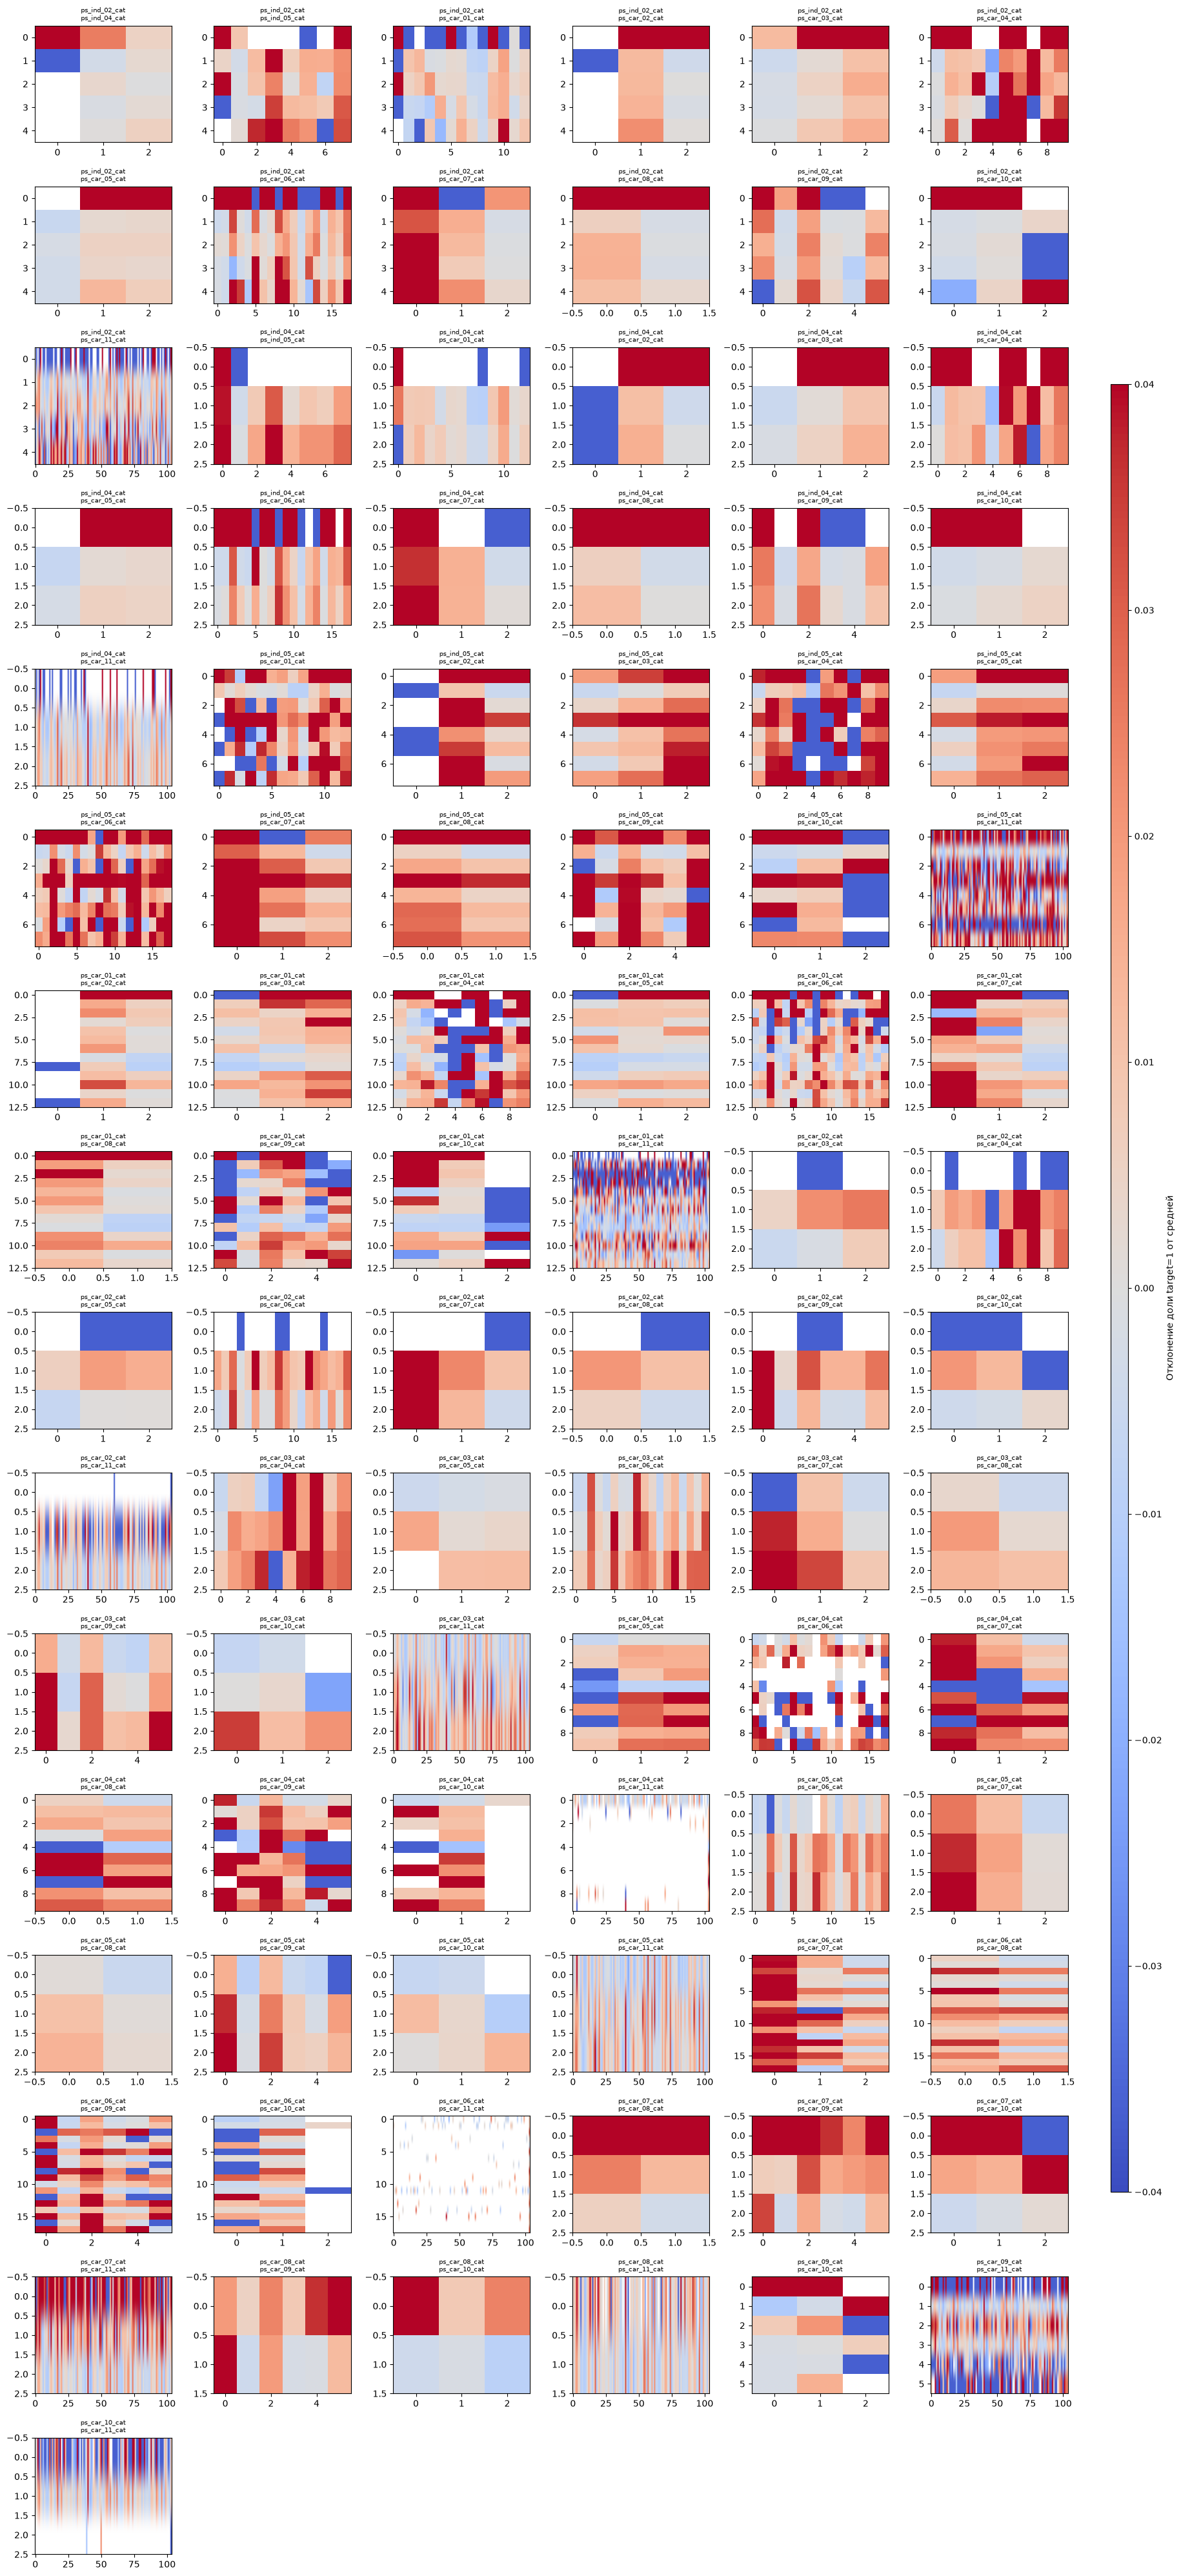

In [273]:
cat_pairs = list(combinations(cat_features, 2))

ncols = 6
nrows = math.ceil(len(cat_pairs) / ncols)

fig,axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, nrows * 2.5),
)

target_mean = train["target"].mean()

for ax, (col_1, col_2) in zip(axes.flat, cat_pairs):
    matrix = train.pivot_table(
        index=col_1,
        columns=col_2,
        values='target',
        aggfunc="mean",
    )

    matrix = matrix - target_mean

    image = ax.imshow(matrix, aspect='auto', cmap='coolwarm', vmin=-0.04,vmax=0.04)

    ax.set_title(f"{col_1}\n{col_2}", fontsize=7)



plt.tight_layout(rect=[0, 0, 0.93, 1])
colorbar_ax = fig.add_axes([0.95, 0.15, 0.015, 0.7])

fig.colorbar(
    image,
    cax=colorbar_ax,
    label="Отклонение доли target=1 от средней",
)

for ax in axes.flat[len(cat_pairs):]:
    ax.axis('off')

plt.show()


### Категориальные признаки

In [235]:
for column in cat_features:
    print(f'{column}:{train[column].unique().size}')

ps_ind_02_cat:5
ps_ind_04_cat:3
ps_ind_05_cat:8
ps_car_01_cat:13
ps_car_02_cat:3
ps_car_03_cat:3
ps_car_04_cat:10
ps_car_05_cat:3
ps_car_06_cat:18
ps_car_07_cat:3
ps_car_08_cat:2
ps_car_09_cat:6
ps_car_10_cat:3
ps_car_11_cat:104


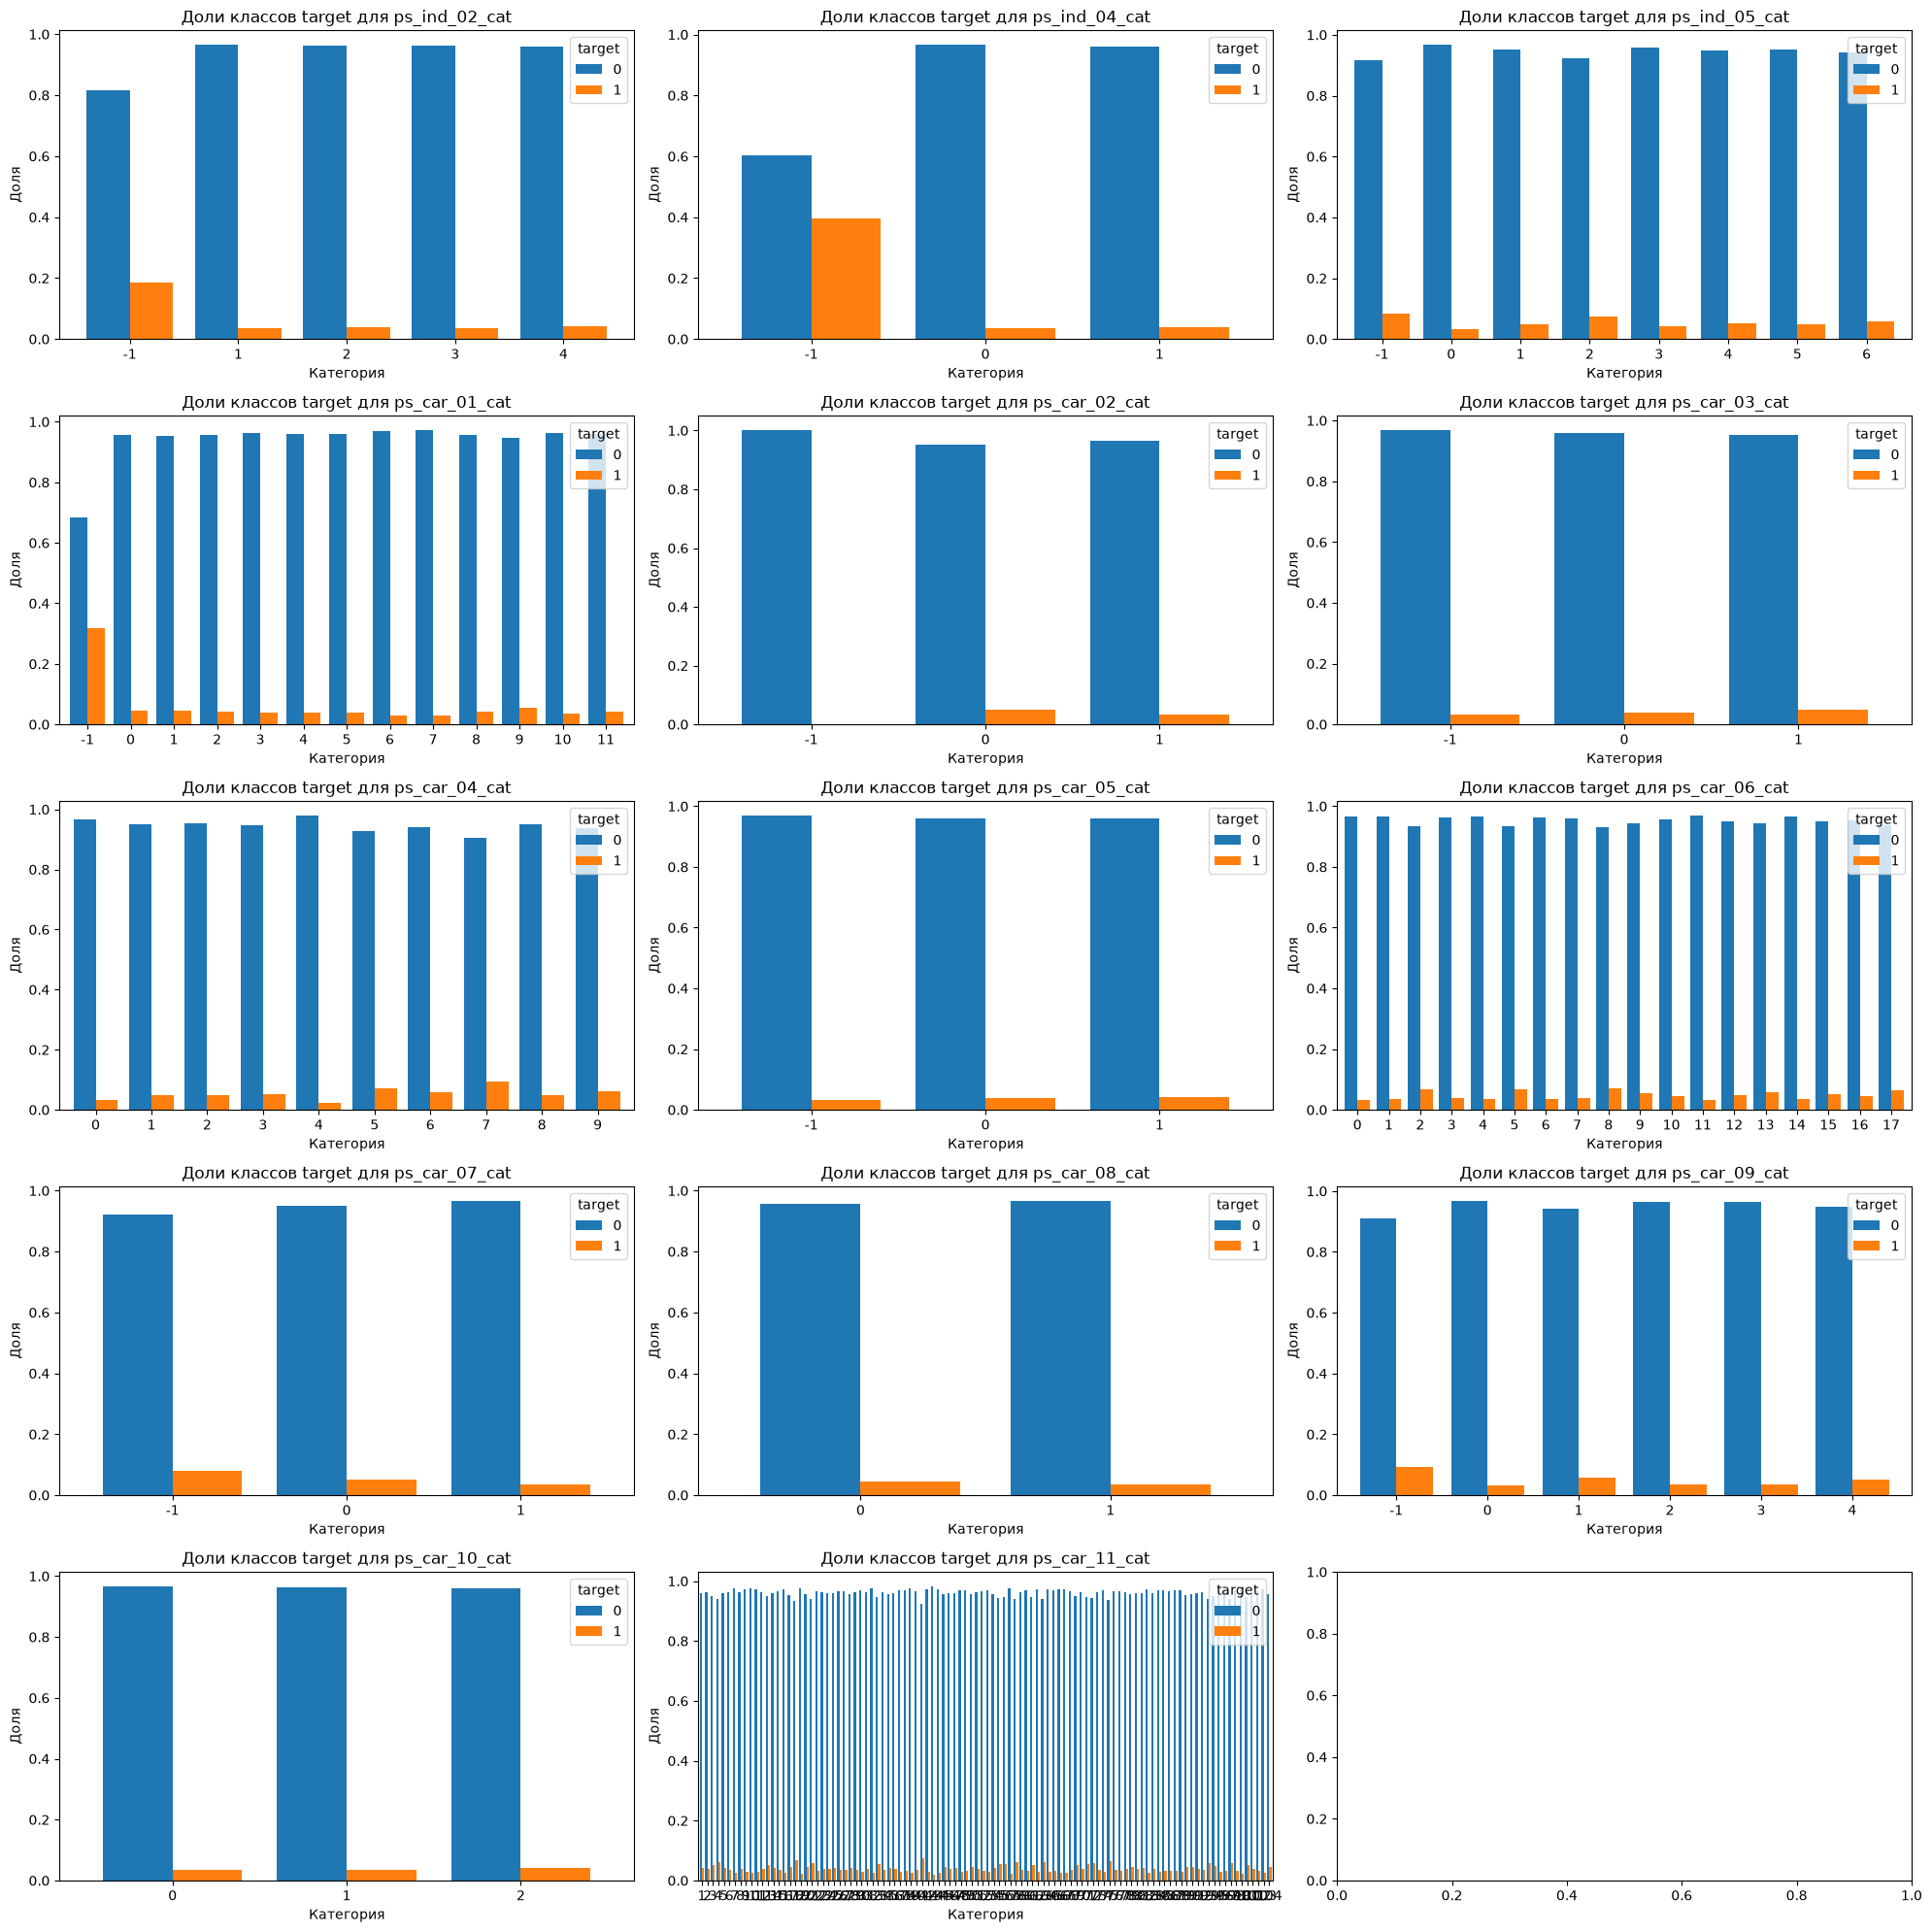

In [236]:
cat_feat_shares_by_target = {}
fig_4, ax_4 = plt.subplots(5,3,figsize=(20,20))

for i in range(len(cat_features)):
    shares = pd.crosstab(
        train[cat_features[i]],
        train["target"],
        normalize="index"
    )

    row = i // 3
    col = i % 3

    shares.plot.bar(
        ax=ax_4[row,col],
        width=0.8,
    )

    ax_4[row, col].set_title(f"Доли классов target для {cat_features[i]}")
    ax_4[row, col].set_xlabel("Категория")
    ax_4[row, col].set_ylabel("Доля")
    ax_4[row, col].legend(title="target")
    ax_4[row, col].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Доля положительного класса высокие значения наблюдаются для категории `-1`, обозначающей пропуск. Однако для `ps_ind_02_cat`, `ps_ind_04_cat` и `ps_car_01_cat` количество пропущенных значений невелико, поэтому высокая доля положительного класса может быть нестабильной. Более надёжными выглядят различия для `ps_ind_05_cat` и `ps_car_07_cat`, где категория `-1` представлена большим количеством объектов.

Из этого можно сделать вывод, что пропуски для ряда признаков следует оставить отдельной категорией.

## Бинарные признаки

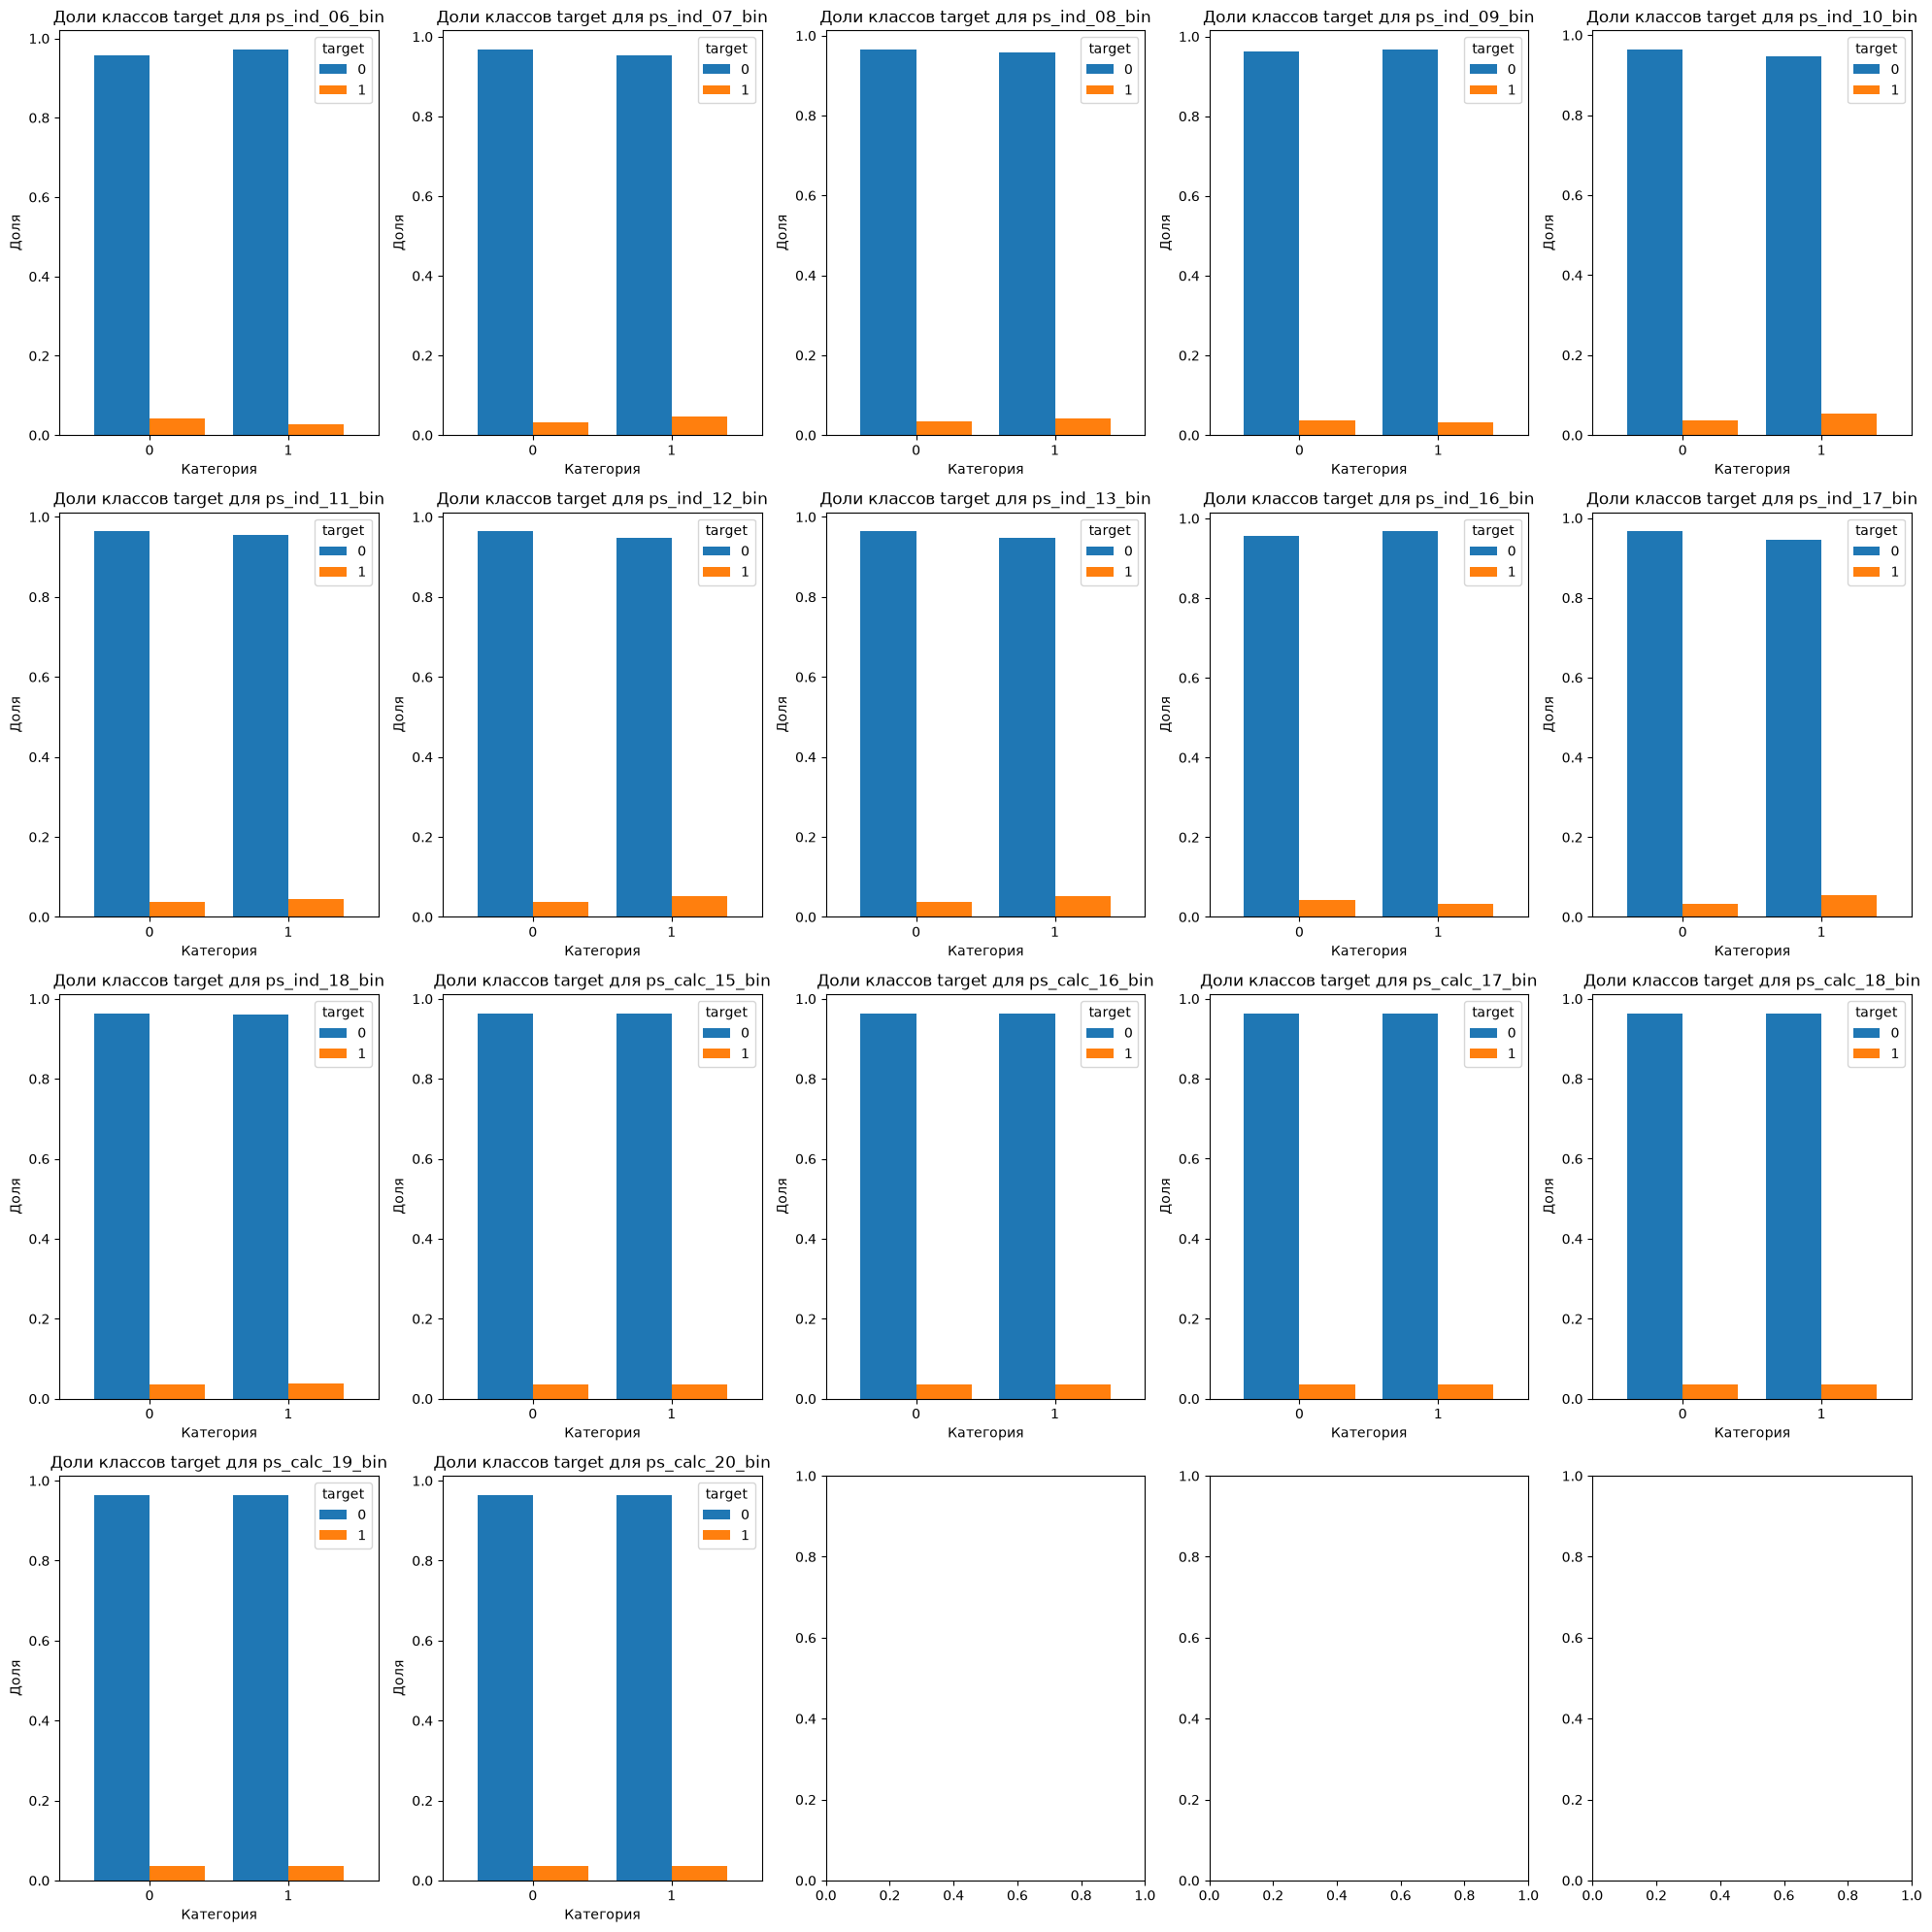

In [237]:
bin_feat_shares_by_target = {}
fig_5, ax_5 = plt.subplots(4,5,figsize=(20,20))

for i in range(len(bin_features)):
    shares = pd.crosstab(
        train[bin_features[i]],
        train["target"],
        normalize="index"
    )

    row = i // 5
    col = i % 5

    shares.plot.bar(
        ax=ax_5[row,col],
        width=0.8,
    )

    ax_5[row, col].set_title(f"Доли классов target для {bin_features[i]}")
    ax_5[row, col].set_xlabel("Категория")
    ax_5[row, col].set_ylabel("Доля")
    ax_5[row, col].legend(title="target")
    ax_5[row, col].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Для бинарных признаков доля положительного класса при значениях 0 и 1 различается незначительно.

## Выводы EDA

1. В целевой переменной наблюдается сильный дисбаланс классов,
2. Пропуски представлены значением -1; для некоторых признаков сам факт пропуска связан с таргетом.
3. Линейная корреляция признаков с таргетом невысока, поэтому одних линейных зависимостей недостаточно.
4. В feature engineering стоит добавить признаки, связанные с пропусками.

# Baseline

In [21]:
def normalized_gini(y_true, y_pred):
    return 2 * roc_auc_score(y_true, y_pred) -1

In [22]:
gini_scorer = make_scorer(
    normalized_gini,
    response_method="predict_proba"
)

# Подготовка данных и кросс-валидация

In [6]:
X_baseline = train.drop(columns=['id', 'target'])
y = train['target']

In [19]:
cv_fast = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED,
)

In [41]:
cv_final = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

Функции предобработки:

In [28]:
ohe_cat = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="passthrough",
)

In [29]:
non_sparse_ohe_cat = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ],
    remainder="passthrough",
)

In [30]:
ohe_cat_scale_num = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features),
        ("bin", "passthrough", bin_features),
    ],
)

Для авто-обработки категорий в lightgbm добавлю предобработку столбцов.

In [14]:
def to_lgbm_categories(X):
    X = X.copy()

    for column in cat_features:
        X[column] = X[column].astype("category")

    return X

Объявим базовые модели. Модели, которые требуют предобработку, обернём в pipeline.
SVM не буду тестировать т.к. на таком количестве признаков он будет слишком долго обучаться.

In [31]:
base_models = {
    # Не ансамблевые методы
    "DecisionTree": make_pipeline(
        ohe_cat,
        DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=SEED),
    ),

    "NaiveBayes": make_pipeline(
        non_sparse_ohe_cat,
        GaussianNB(),
    ),

    "LogisticRegression": make_pipeline(
        ohe_cat_scale_num,
        LogisticRegression(max_iter=3000, random_state=SEED),
    ),

    # Бэггинг
    "RandomForest": make_pipeline(
        ohe_cat,
        RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=20, random_state=SEED, n_jobs=-1,),
    ),

    "ExtraTrees": make_pipeline(
        ohe_cat,
        ExtraTreesClassifier(n_estimators=300, max_depth=15,min_samples_leaf=20, random_state=SEED, n_jobs=-1,),
    ),

    # Бустинги
    "XGBoost": make_pipeline(
        ohe_cat,
        XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, eval_metric="auc", objective="binary:logistic", random_state=SEED),
    ),

    "LightGBM": make_pipeline(
        FunctionTransformer(to_lgbm_categories),
        LGBMClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,  random_state=SEED),
    ),

    "CatBoost": CatBoostClassifier(iterations=300, max_depth=3, learning_rate=0.1, eval_metric="AUC", random_state=SEED,),

}

In [17]:
def evaluate_models(models, X, y, cv):
    results = []

    for model_name, model in models.items():
        print(f"Оценивается: {model_name}")

        fit_params = None

        if model_name == "CatBoost":
            fit_params = {
                "cat_features": cat_features,
            }

        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring=gini_scorer,
            n_jobs=1,
            params=fit_params,
        )

        results.append({
            "model_name": model_name,
            "mean_gini": scores.mean(),
            "std_gini": scores.std(),
        })

    return (
        pd.DataFrame(results)
        .sort_values("mean_gini", ascending=False)
        .reset_index(drop=True)
    )

In [32]:
baseline_results = evaluate_models(base_models, X_baseline, y, cv_fast)

Оценивается: DecisionTree
Оценивается: NaiveBayes
Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: ExtraTrees
Оценивается: XGBoost
Оценивается: LightGBM
Оценивается: CatBoost
0:	total: 324ms	remaining: 1m 36s
1:	total: 478ms	remaining: 1m 11s
2:	total: 632ms	remaining: 1m 2s
3:	total: 786ms	remaining: 58.1s
4:	total: 936ms	remaining: 55.2s
5:	total: 1.07s	remaining: 52.5s
6:	total: 1.21s	remaining: 50.7s
7:	total: 1.34s	remaining: 48.9s
8:	total: 1.49s	remaining: 48.1s
9:	total: 1.64s	remaining: 47.7s
10:	total: 1.79s	remaining: 47.1s
11:	total: 1.93s	remaining: 46.3s
12:	total: 2.08s	remaining: 45.8s
13:	total: 2.22s	remaining: 45.4s
14:	total: 2.37s	remaining: 45s
15:	total: 2.5s	remaining: 44.4s
16:	total: 2.64s	remaining: 44s
17:	total: 2.77s	remaining: 43.5s
18:	total: 2.92s	remaining: 43.2s
19:	total: 3.05s	remaining: 42.6s
20:	total: 3.17s	remaining: 42.2s
21:	total: 3.29s	remaining: 41.6s
22:	total: 3.43s	remaining: 41.3s
23:	total: 3.56s	remaining: 40.9s


In [251]:
display(baseline_results)

,model_name,mean_gini,std_gini
0,XGBoost,0.277778,0.005824
1,CatBoost,0.274793,0.006487
2,RandomForest,0.268690,0.004250
3,ExtraTrees,0.259784,0.004778
4,LogisticRegression,0.259754,0.005277
5,LightGBM,0.257637,0.002917
6,DecisionTree,0.193067,0.007826
7,NaiveBayes,0.180246,0.008117


Посмотрим результаты разных baseline моделей с наивысшими результатами на тесте.

In [254]:
candidate_models = {
    name: base_models[name]
    for name in ['XGBoost', 'RandomForest', 'LogisticRegression', 'LightGBM']
}

In [255]:
test_results_baseline_v1 = {}
for name, model in candidate_models.items():

    model.fit(X_baseline, y)

    X_test_baseline_v1  = test[X_baseline.columns]

    test_results_baseline_v1[name] = model.predict_proba(X_test_baseline_v1)[:,1]

[LightGBM] [Info] Number of positive: 21694, number of negative: 573518
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 595212, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274754
[LightGBM] [Info] Start training from score -3.274754
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [259]:
sub_baseline_v1 = {}
for name, model in candidate_models.items():
    sub_baseline_v1[name] = pd.DataFrame({
        'id': test['id'],
        'target': test_results_baseline_v1[name],
    })

In [260]:
for name,_ in sub_baseline_v1.items():
    sub_baseline_v1[name].to_csv(f"sub_{name}_v1.csv", index=False)

In [270]:
sub_baseline_v1_names = ['sub_XGBoost_v1.csv','sub_LightGBM_v1.csv', 'sub_LogisticRegression_v1.csv','sub_RandomForest_v1.csv']
sub_baseline_v1_private_score = [0.28089,0.26920, 0.26662,0.26953]
sub_baseline_v1_public_score = [0.27785, 0.26404, 0.25983,0.26583]

In [271]:
sub_baseline_v1_results = pd.DataFrame({
    'Submission': sub_baseline_v1_names,
    'Private Score': sub_baseline_v1_private_score,
    'Public Score': sub_baseline_v1_public_score,
})
sub_baseline_v1_results.sort_values('Public Score', ascending=False, inplace=True)
display(sub_baseline_v1_results)

,Submission,Private Score,Public Score
0,sub_XGBoost_v1.csv,0.28089,0.27785
3,sub_RandomForest_v1.csv,0.26953,0.26583
1,sub_LightGBM_v1.csv,0.26920,0.26404
2,sub_LogisticRegression_v1.csv,0.26662,0.25983


Результаты схожи с train, значит пока что движемся в правильном направлении.

# Features engineering и обработка пропусков

Все варианты feature engineering сравниваются:

- на одинаковых разбиениях StratifiedKFold;
- по метрике normalized Gini;
- с фиксированным random_state;
- на неизменных параметрах моделей;
- без использования тестовой выборки Kaggle;

## 1. Raw

In [272]:
display(baseline_results)

,model_name,mean_gini,std_gini
0,XGBoost,0.277778,0.005824
1,CatBoost,0.274793,0.006487
2,RandomForest,0.268690,0.004250
3,ExtraTrees,0.259784,0.004778
4,LogisticRegression,0.259754,0.005277
5,LightGBM,0.257637,0.002917
6,DecisionTree,0.193067,0.007826
7,NaiveBayes,0.180246,0.008117


In [277]:
logistic_model = LogisticRegression(
    max_iter=3000,
    random_state=SEED,
)

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=20,
    random_state=SEED,
    n_jobs=-1,
)

xgboost_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="auc",
    objective="binary:logistic",
    random_state=SEED,
)

lightgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    random_state=SEED,
)

Функция для сравнения с baseline

In [24]:
def compare_with_baseline(results):
    baseline = baseline_results[
        baseline_results["model_name"].isin(
            results["model_name"]
        )
    ]

    comparison = baseline.merge(
        results,
        on="model_name",
        suffixes=("_baseline", "_new"),
    )

    comparison["delta_gini"] = (
        comparison["mean_gini_new"]
        - comparison["mean_gini_baseline"]
    )

    return comparison.sort_values(
        "delta_gini",
        ascending=False,
    )

## 2. Признаки пропусков

### Категориальные признаки

#### `-1` отдельной категорией

Используем в baseline

#### Мода

In [278]:
cat_mode_ohe = make_pipeline(
    SimpleImputer(missing_values=-1,strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"),
)

In [279]:
cat_mode_tree_preprocessor = ColumnTransformer(
    [
        ("cat", cat_mode_ohe, cat_features),
    ],
    remainder="passthrough",
)

In [280]:
cat_mode_log_preprocessor = ColumnTransformer(
    [
        ("cat", cat_mode_ohe, cat_features),
        ("num", StandardScaler(), num_features),
    ],
    remainder="passthrough",
)

In [283]:
cat_mode_lgbm_preprocessor = ColumnTransformer(
    [
        ("cat", SimpleImputer(missing_values=-1,strategy="most_frequent",), cat_features,),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

In [284]:
cat_mode_models = {
    "LogisticRegression": make_pipeline(
        cat_mode_log_preprocessor,
        logistic_model,
    ),

    "RandomForest": make_pipeline(
        cat_mode_tree_preprocessor,
        random_forest_model,
    ),

    "XGBoost": make_pipeline(
        cat_mode_tree_preprocessor,
        xgboost_model,
    ),

    "LightGBM": make_pipeline(
        cat_mode_lgbm_preprocessor,
        FunctionTransformer(
            to_lgbm_categories,
            validate=False,
        ),
        lightgbm_model,
    ),
}

In [285]:
 cat_mode_results = evaluate_models(
    cat_mode_models,
    X_baseline,
    y,
    cv_fast,
)

compare_with_baseline(cat_mode_results)

Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026831 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1367
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
0,XGBoost,0.277778,0.005824,0.276997,0.005061,-0.000781
3,LightGBM,0.257637,0.002917,0.256795,0.002794,-0.000842
1,RandomForest,0.268690,0.004250,0.266832,0.004840,-0.001858
2,LogisticRegression,0.259754,0.005277,0.252589,0.004659,-0.007165


#### Мода + индикатор

Добавим индикатор пропусков только для тех фич, которые занимали значимое долю от общей массы и была заметна зависимость с таргетом.

In [286]:
missing_indicator_features = [
    "ps_car_03_cat",
    "ps_car_05_cat",
    "ps_car_07_cat",
    "ps_ind_05_cat",
]

X_cat_mode_indicator = X_baseline.copy()

for col in missing_indicator_features:
    X_cat_mode_indicator[
        f"{col}_is_miss"
    ] = X_cat_mode_indicator[col].eq(-1).astype(int)

In [287]:
cat_mode_indicator_results = evaluate_models(
    cat_mode_models,
    X_cat_mode_indicator,
    y,
    cv_fast,
)

compare_with_baseline(cat_mode_indicator_results)

Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1375
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
1,RandomForest,0.268690,0.004250,0.269063,0.004889,0.000373
3,LightGBM,0.257637,0.002917,0.257921,0.003054,0.000284
0,XGBoost,0.277778,0.005824,0.277264,0.004593,-0.000514
2,LogisticRegression,0.259754,0.005277,0.259016,0.005446,-0.000738


### Числовые признаки

#### Медиана

In [290]:
num_median_tree_preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", SimpleImputer(missing_values=-1,strategy="median"), num_features),
    ],
    remainder="passthrough",
)

In [291]:
num_median_log_preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num",make_pipeline(
            SimpleImputer(missing_values=-1,strategy="median"),
            StandardScaler(),
         ), num_features ),
    ],
    remainder="passthrough",
)

In [292]:
num_median_lgbm_preprocessor = ColumnTransformer(
    [
        ("num", SimpleImputer(missing_values=-1, strategy="median"), num_features),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

In [293]:
num_median_models = {
    "LogisticRegression": make_pipeline(
        num_median_log_preprocessor,
        logistic_model,
    ),

    "RandomForest": make_pipeline(
        num_median_tree_preprocessor,
        random_forest_model,
    ),

    "XGBoost": make_pipeline(
        num_median_tree_preprocessor,
        xgboost_model,
    ),

    "LightGBM": make_pipeline(
        num_median_lgbm_preprocessor,
        FunctionTransformer(
            to_lgbm_categories,
            validate=False,
        ),
        lightgbm_model,
    ),
}

In [294]:
num_median_results = evaluate_models(
    num_median_models,
    X_baseline,
    y,
    cv_fast,
)

compare_with_baseline(num_median_results)

Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022599 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1372
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
1,RandomForest,0.268690,0.004250,0.268670,0.004067,-0.000020
0,XGBoost,0.277778,0.005824,0.277498,0.004770,-0.000279
3,LightGBM,0.257637,0.002917,0.256610,0.002927,-0.001027
2,LogisticRegression,0.259754,0.005277,0.258386,0.005448,-0.001368


#### Медиана + индикаторы

In [295]:
num_missing_features = [
    col for col in num_features
    if X_baseline[col].eq(-1).any()
]

X_num_median_indicator = X_baseline.copy()

for col in num_missing_features:
    X_num_median_indicator[
        f"{col}_is_miss"
    ] = X_num_median_indicator[col].eq(-1).astype(int)

In [296]:
num_median_indicator_results = evaluate_models(
    num_median_models,
    X_num_median_indicator,
    y,
    cv_fast,
)

compare_with_baseline(num_median_indicator_results)

Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1376
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
0,XGBoost,0.277778,0.005824,0.277463,0.005124,-0.000314
1,RandomForest,0.268690,0.004250,0.268205,0.004565,-0.000485
2,LogisticRegression,0.259754,0.005277,0.259136,0.005338,-0.000618
3,LightGBM,0.257637,0.002917,0.255719,0.002322,-0.001919


### Агрегат пропусков

In [298]:
feature_log_preprocessor = ColumnTransformer(
    [
        ("cat",OneHotEncoder(handle_unknown="ignore"),cat_features),
        ("num", StandardScaler(), num_features),
    ],
    remainder="passthrough",
)

In [299]:
feature_models = {
    "LogisticRegression": make_pipeline(
        feature_log_preprocessor,
        logistic_model,
    ),

    "RandomForest": make_pipeline(
        ohe_cat,
        random_forest_model,
    ),

    "XGBoost": make_pipeline(
        ohe_cat,
        xgboost_model,
    ),

    "LightGBM": make_pipeline(
        FunctionTransformer(
            to_lgbm_categories,
            validate=False,
        ),
        lightgbm_model,
    ),
}

### Общий счётчик

In [300]:
X_missing_count = X_baseline.copy()

X_missing_count["missings_count"] = (X_baseline == -1).sum(axis=1)

In [301]:
missing_count_results = evaluate_models(
    feature_models,
    X_missing_count,
    y,
    cv_fast,
)

compare_with_baseline(missing_count_results)

Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1381
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
0,XGBoost,0.277778,0.005824,0.277963,0.004944,0.000186
2,LogisticRegression,0.259754,0.005277,0.259865,0.005423,0.000111
1,RandomForest,0.268690,0.004250,0.268557,0.004457,-0.000133
3,LightGBM,0.257637,0.002917,0.257259,0.003016,-0.000378


### Счётчики по типам

In [302]:
X_missing_group_counts = X_baseline.copy()

X_missing_group_counts["num_missing_count"] = (X_baseline[num_features] == -1).sum(axis=1)
X_missing_group_counts["cat_missing_count"] = (X_baseline[cat_features] == -1).sum(axis=1)

In [303]:
missing_group_results = evaluate_models(
    feature_models,
    X_missing_group_counts,
    y,
    cv_fast,
)

compare_with_baseline(missing_group_results)

Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
0,XGBoost,0.277778,0.005824,0.278487,0.005140,0.000709
1,RandomForest,0.268690,0.004250,0.269134,0.004858,0.000444
3,LightGBM,0.257637,0.002917,0.257577,0.003024,-0.000061
2,LogisticRegression,0.259754,0.005277,0.259379,0.005519,-0.000375


## 2. Бинарные агрегаты

### Исходные + агрегаты

In [307]:
ind_bin_features = [col for col in bin_features if col.startswith("ps_ind_")]

calc_bin_features = [col for col in bin_features if col.startswith("ps_calc_")]

X_bin_aggregates = X_baseline.copy()

X_bin_aggregates["ind_bin_sum"] = X_baseline[ind_bin_features].sum(axis=1)
X_bin_aggregates["calc_bin_sum"] = X_baseline[calc_bin_features].sum(axis=1)

In [308]:
bin_aggregates_results = evaluate_models(
    feature_models,
    X_bin_aggregates,
    y,
    cv_fast,
)

compare_with_baseline(bin_aggregates_results)

Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1387
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
0,XGBoost,0.277778,0.005824,0.278284,0.004959,0.000506
1,RandomForest,0.268690,0.004250,0.269120,0.005363,0.000430
2,LogisticRegression,0.259754,0.005277,0.259296,0.005004,-0.000458
3,LightGBM,0.257637,0.002917,0.257050,0.002583,-0.000587


### Только агрегаты

Удалить исходные бинарные признаки, оставить ind_bin_sum и calc_bin_sum

In [309]:
X_only_bin_aggregates = X_bin_aggregates.drop(columns = bin_features)

In [310]:
only_bin_aggregates_results = evaluate_models(
    feature_models,
    X_only_bin_aggregates,
    y,
    cv_fast,
)

compare_with_baseline(only_bin_aggregates_results)

Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1353
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
0,XGBoost,0.277778,0.005824,0.266265,0.003137,-0.011512
1,RandomForest,0.268690,0.004250,0.256143,0.004374,-0.012547
3,LightGBM,0.257637,0.002917,0.244900,0.003825,-0.012737
2,LogisticRegression,0.259754,0.005277,0.246703,0.004658,-0.013052


## 3. Ablation групп признаков

### без бинарных признаков

Полностью удалить все _bin

In [311]:
X_without_bin = X_baseline.drop(
    columns=bin_features
)

In [312]:
without_bin_results = evaluate_models(
    feature_models,
    X_without_bin,
    y,
    cv_fast,
)

compare_with_baseline(without_bin_results)

Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1339
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
0,XGBoost,0.277778,0.005824,0.266575,0.002927,-0.011203
1,RandomForest,0.268690,0.004250,0.256496,0.003295,-0.012194
3,LightGBM,0.257637,0.002917,0.244729,0.003687,-0.012908
2,LogisticRegression,0.259754,0.005277,0.246693,0.004809,-0.013061


### без `ps_calc_*`

In [313]:
calc_features = [col for col in X_baseline.columns if col.startswith("ps_calc_")]

X_without_calc = X_baseline.drop(columns=calc_features)

num_without_calc = [col for col in num_features if col not in calc_features]

In [314]:
without_calc_log_preprocessor = ColumnTransformer(
    [
        ("cat",OneHotEncoder(handle_unknown="ignore"),cat_features),
        ("num", StandardScaler(), num_without_calc),
    ],
    remainder="passthrough",
)

In [315]:
without_calc_models = {
    "LogisticRegression": make_pipeline(
        without_calc_log_preprocessor,
        logistic_model,
    ),

    "RandomForest": make_pipeline(
        ohe_cat,
        random_forest_model,
    ),

    "XGBoost": make_pipeline(
        ohe_cat,
        xgboost_model,
    ),

    "LightGBM": make_pipeline(
        FunctionTransformer(
            to_lgbm_categories,
            validate=False,
        ),
        lightgbm_model,
    ),
}

In [316]:
without_calc_results = evaluate_models(
    without_calc_models,
    X_without_calc,
    y,
    cv_fast,
)

compare_with_baseline(without_calc_results)

Оценивается: LogisticRegression
Оценивается: RandomForest
Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018580 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1184
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
1,RandomForest,0.268690,0.004250,0.271503,0.004079,0.002813
3,LightGBM,0.257637,0.002917,0.260427,0.003497,0.002790
0,XGBoost,0.277778,0.005824,0.279336,0.005398,0.001558
2,LogisticRegression,0.259754,0.005277,0.259691,0.005483,-0.000063


### только `ps_calc_*`

In [317]:
X_only_calc = X_baseline[calc_features].copy()

In [318]:
only_calc_models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        logistic_model,
    ),

    "RandomForest": random_forest_model,

    "XGBoost": xgboost_model,

    "LightGBM": lightgbm_model,
}

In [319]:
only_calc_results = evaluate_models(
    only_calc_models,
    X_only_calc,
    y,
    cv_fast,
)

compare_with_baseline(only_calc_results)

Оценивается: LogisticRegression
Оценивается: RandomForest


C:\Users\alesh\Documents\Apps and Data\GITHUB\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "C:\Users\alesh\Documents\Apps and Data\GITHUB\.venv\Lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alesh\Documents\Apps and Data\GITHUB\.venv\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
            ^^^^^^^^

Оценивается: XGBoost
Оценивается: LightGBM
[LightGBM] [Info] Number of positive: 14463, number of negative: 382345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017337 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 189
[LightGBM] [Info] Number of data points in the train set: 396808, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274730
[LightGBM] [Info] Start training from score -3.274730
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

C:\Users\alesh\Documents\Apps and Data\GITHUB\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\alesh\Documents\Apps and Data\GITHUB\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\alesh\Documents\Apps and Data\GITHUB\.venv\Lib\site-packages\lightgbm\sklearn.py", line 1704, in fit
    super().fit(
  File "C:\Users\alesh\Documents\Apps and Data\GITHUB\.venv\Lib\site-packages\lightgbm\sklearn.py", line 1171, in fit
    se

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
2,LogisticRegression,0.259754,0.005277,-0.001266,0.002576,-0.261020
0,XGBoost,0.277778,0.005824,0.003341,0.003546,-0.274436
1,RandomForest,0.268690,0.004250,NaN,NaN,NaN
3,LightGBM,0.257637,0.002917,NaN,NaN,NaN


## Совмещение полезных изменений

- удаление группы `ps_calc_*`;
- количество пропусков отдельно в числовых и категориальных признаках;
- сумма бинарных признаков группы `ps_ind_*`.

In [4]:
def build_all_features(X):
    X_new = X.copy(deep=False)

    current_num_features = [
        col for col in num_features
        if col in X_new.columns
    ]

    current_cat_features = [
        col for col in cat_features
        if col in X_new.columns
    ]

    ind_bin_features = [
        col for col in bin_features
        if col.startswith("ps_ind_")
        and col in X_new.columns
    ]

    calc_bin_features = [
        col for col in bin_features
        if col.startswith("ps_calc_")
        and col in X_new.columns
    ]

    # Счётчики пропусков
    X_new["num_missing_count"] = (
        X_new[current_num_features]
        .eq(-1)
        .sum(axis=1)
    )

    X_new["cat_missing_count"] = (
        X_new[current_cat_features]
        .eq(-1)
        .sum(axis=1)
    )

    # Суммы бинарных признаков
    X_new["ind_bin_sum"] = (
        X_new[ind_bin_features]
        .sum(axis=1)
    )

    X_new["calc_bin_sum"] = (
        X_new[calc_bin_features]
        .sum(axis=1)
    )

    # Удаляем исходные ps_calc_*
    calc_features = [
        col for col in X_new.columns
        if col.startswith("ps_calc_")
    ]

    X_new = X_new.drop(columns=calc_features)

    return X_new

In [7]:
X_all_features = build_all_features(
    X_baseline
)

X_all_features.shape

(595212, 41)

In [8]:
X_test_baseline = test.drop(
    columns=["id"],
    errors="ignore",
)

X_test_all_features = build_all_features(
    X_test_baseline
)

In [9]:
new_features = [
    "num_missing_count",
    "cat_missing_count",
    "ind_bin_sum",
    "calc_bin_sum",
]

final_num_features = [
    col for col in num_features
    if col in X_all_features.columns
] + new_features

final_cat_features = [
    col for col in cat_features
    if col in X_all_features.columns
]

final_bin_features = [
    col for col in bin_features
    if col in X_all_features.columns
]

In [10]:
final_log_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            final_cat_features,
        ),
        (
            "num",
            StandardScaler(),
            final_num_features,
        ),
        (
            "bin",
            "passthrough",
            final_bin_features,
        ),
    ],
    remainder="drop",
)

final_tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            final_cat_features,
        ),
    ],
    remainder="passthrough",
)

In [15]:
feature_models = {
    "LogisticRegression": make_pipeline(
        final_log_preprocessor,
        LogisticRegression(
            max_iter=3000,
            random_state=SEED,
        ),
    ),

    "RandomForest": make_pipeline(
        final_tree_preprocessor,
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=20,
            random_state=SEED,
            n_jobs=-1,
        ),
    ),

    "XGBoost": make_pipeline(
        final_tree_preprocessor,
        XGBClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.1,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=SEED,
            n_jobs=-1,
        ),
    ),

    "LightGBM": make_pipeline(
        FunctionTransformer(
            to_lgbm_categories,
            validate=False,
        ),
        LGBMClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.1,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        ),
    ),
}

In [ ]:
all_features_results = evaluate_models(
    feature_models,
    X_all_features,
    y,
    cv_fast,
)

In [33]:
compare_with_baseline(all_features_results)

,model_name,mean_gini_baseline,std_gini_baseline,mean_gini_new,std_gini_new,delta_gini
1,RandomForest,0.268690,0.004250,0.271045,0.003759,0.002355
3,LightGBM,0.257637,0.002917,0.259853,0.003382,0.002216
0,XGBoost,0.277778,0.005824,0.279143,0.004905,0.001365
2,LogisticRegression,0.259754,0.005277,0.259759,0.005446,0.000005


## Подбор гиперпараметров

In [34]:
tuning_models = {
    "LogisticRegression": feature_models["LogisticRegression"],
    "XGBoost": feature_models["XGBoost"],
    "LightGBM": feature_models["LightGBM"],
}

In [35]:
param_grids = {
    "LogisticRegression": {
        "logisticregression__C": [0.1, 1, 10],
        "logisticregression__class_weight": [None, "balanced"],
    },

    "XGBoost": {
        "xgbclassifier__n_estimators": [300, 500],
        "xgbclassifier__max_depth": [3, 4],
        "xgbclassifier__learning_rate": [0.03, 0.05],

        "xgbclassifier__min_child_weight": [5],
        "xgbclassifier__subsample": [0.8],
        "xgbclassifier__colsample_bytree": [0.8],
        "xgbclassifier__reg_alpha": [0.1],
        "xgbclassifier__reg_lambda": [1],
    },

    "LightGBM": [
    {
        "lgbmclassifier__n_estimators": [1000, 1400],
        "lgbmclassifier__learning_rate": [0.005, 0.01, 0.02],

        "lgbmclassifier__num_leaves": [31],
        "lgbmclassifier__min_child_samples": [1500],
        "lgbmclassifier__max_bin": [255],

        "lgbmclassifier__colsample_bytree": [0.7],
        "lgbmclassifier__subsample": [0.7],
        "lgbmclassifier__subsample_freq": [1],

        "lgbmclassifier__reg_alpha": [1],
        "lgbmclassifier__reg_lambda": [1],
    },

    {
        "lgbmclassifier__n_estimators": [1000, 1400],
        "lgbmclassifier__learning_rate": [0.005, 0.01, 0.02],

        "lgbmclassifier__num_leaves": [24],
        "lgbmclassifier__min_child_samples": [24],
        "lgbmclassifier__max_bin": [255],

        "lgbmclassifier__colsample_bytree": [0.9],
        "lgbmclassifier__subsample": [0.5],
        "lgbmclassifier__subsample_freq": [1],

        "lgbmclassifier__reg_alpha": [10],
        "lgbmclassifier__reg_lambda": [1],
    },
]
}

In [38]:
best_feature_models = {}
tuning_rows = []

for model_name, model in tuning_models.items():
    print(f"\nПодбор параметров: {model_name}")

    search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        scoring=gini_scorer,
        cv=cv_fast,
        n_jobs=1,
        verbose=2,
        refit=True,
        error_score="raise",
    )

    search.fit(
        X_all_features,
        y,
    )

    best_feature_models[model_name] = search.best_estimator_

    tuning_rows.append({
        "model_name": model_name,
        "best_mean_gini": search.best_score_,
        "best_params": search.best_params_,
    })


Подбор параметров: LogisticRegression
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END logisticregression__C=0.1, logisticregression__class_weight=None; total time=   2.4s
[CV] END logisticregression__C=0.1, logisticregression__class_weight=None; total time=   2.1s
[CV] END logisticregression__C=0.1, logisticregression__class_weight=None; total time=   2.0s
[CV] END logisticregression__C=0.1, logisticregression__class_weight=balanced; total time=   5.1s
[CV] END logisticregression__C=0.1, logisticregression__class_weight=balanced; total time=   5.0s
[CV] END logisticregression__C=0.1, logisticregression__class_weight=balanced; total time=   4.3s
[CV] END logisticregression__C=1, logisticregression__class_weight=None; total time=   2.7s
[CV] END logisticregression__C=1, logisticregression__class_weight=None; total time=   2.1s
[CV] END logisticregression__C=1, logisticregression__class_weight=None; total time=   2.2s
[CV] END logisticregression__C=1, logisticregress

In [39]:
tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        "best_mean_gini",
        ascending=False,
    )
    .reset_index(drop=True)
)

tuning_results

,model_name,best_mean_gini,best_params
0,XGBoost,0.283306,"{'xgbclassifier__colsample_bytree': 0.8, 'xgbc..."
1,LightGBM,0.276392,"{'lgbmclassifier__colsample_bytree': 0.7, 'lgb..."
2,LogisticRegression,0.260547,"{'logisticregression__C': 0.1, 'logisticregres..."


In [42]:
tuned_final_results = evaluate_models(
    best_feature_models,
    X_all_features,
    y,
    cv_final,
)

tuned_final_results

Оценивается: LogisticRegression
Оценивается: XGBoost
Оценивается: LightGBM


,model_name,mean_gini,std_gini
0,XGBoost,0.284271,0.007343
1,LightGBM,0.276800,0.006271
2,LogisticRegression,0.261295,0.007211


## Ансамбли лучших моделей

In [43]:
ensemble_models = {
    "LogisticRegression": best_feature_models[
        "LogisticRegression"
    ],
    "XGBoost": best_feature_models[
        "XGBoost"
    ],
    "LightGBM": best_feature_models[
        "LightGBM"
    ],
}

## Blending

OOF-предсказания базовых моделей

In [46]:
oof_predictions = pd.DataFrame(
    index=X_all_features.index
)

for model_name, model in ensemble_models.items():
    print(f"OOF: {model_name}")

    oof_predictions[model_name] = cross_val_predict(
        estimator=model,
        X=X_all_features,
        y=y,
        cv=cv_final,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]

OOF: LogisticRegression
OOF: XGBoost
OOF: LightGBM


Обычное среднее вероятностей

In [47]:
oof_predictions["Blending"] = (
    oof_predictions[
        [
            "LogisticRegression",
            "XGBoost",
            "LightGBM",
        ]
    ]
    .mean(axis=1)
)

Weighted soft voting

In [50]:
weighted_voting_model = VotingClassifier(
    estimators=[
        (
            "logreg",
            clone(
                ensemble_models[
                    "LogisticRegression"
                ]
            ),
        ),
        (
            "xgb",
            clone(
                ensemble_models[
                    "XGBoost"
                ]
            ),
        ),
        (
            "lgbm",
            clone(
                ensemble_models[
                    "LightGBM"
                ]
            ),
        ),
    ],
    voting="soft",
    weights=[1, 2, 2],
    n_jobs=1,
)

In [51]:
oof_predictions["WeightedVoting"] = (
    cross_val_predict(
        estimator=weighted_voting_model,
        X=X_all_features,
        y=y,
        cv=cv_final,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]
)

## Stacking

In [52]:
stacking_model = StackingClassifier(
    estimators=[
        (
            "logreg",
            clone(
                ensemble_models[
                    "LogisticRegression"
                ]
            ),
        ),
        (
            "xgb",
            clone(
                ensemble_models[
                    "XGBoost"
                ]
            ),
        ),
        (
            "lgbm",
            clone(
                ensemble_models[
                    "LightGBM"
                ]
            ),
        ),
    ],
    final_estimator=LogisticRegression(
        C=1.0,
        max_iter=3000,
        random_state=SEED,
    ),
    stack_method="predict_proba",
    cv=cv_fast,
    passthrough=False,
    n_jobs=1,
)

In [53]:
oof_predictions["Stacking"] = (
    cross_val_predict(
        estimator=stacking_model,
        X=X_all_features,
        y=y,
        cv=cv_final,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]
)

Сравнениее

In [54]:
ensemble_results = pd.DataFrame({
    "model_name": oof_predictions.columns,

    "oof_gini": [
        normalized_gini(
            y,
            oof_predictions[column],
        )
        for column in oof_predictions.columns
    ],
})

In [55]:
ensemble_results = (
    ensemble_results
    .sort_values(
        "oof_gini",
        ascending=False,
    )
    .reset_index(drop=True)
)

ensemble_results

,model_name,oof_gini
0,XGBoost,0.284174
1,WeightedVoting,0.282079
2,Stacking,0.280928
3,Blending,0.280587
4,LightGBM,0.276698
5,LogisticRegression,0.261206


# Обучение на всём train

In [56]:
test_predictions = pd.DataFrame(
    index=X_test_all_features.index
)

fitted_base_models = {}

for model_name, model in ensemble_models.items():
    print(f"Обучение: {model_name}")

    fitted_model = clone(model)

    fitted_model.fit(
        X_all_features,
        y,
    )

    fitted_base_models[model_name] = fitted_model

    test_predictions[model_name] = (
        fitted_model.predict_proba(
            X_test_all_features
        )[:, 1]
    )

Обучение: LogisticRegression
Обучение: XGBoost
Обучение: LightGBM


blending на test

In [57]:
test_predictions["Blending"] = (
    test_predictions[
        [
            "LogisticRegression",
            "XGBoost",
            "LightGBM",
        ]
    ]
    .mean(axis=1)
)

Weighted voting на test

In [58]:
weighted_voting_model.fit(
    X_all_features,
    y,
)

test_predictions["WeightedVoting"] = (
    weighted_voting_model.predict_proba(
        X_test_all_features
    )[:, 1]
)

Stacking на test

In [59]:
stacking_model.fit(
    X_all_features,
    y,
)

test_predictions["Stacking"] = (
    stacking_model.predict_proba(
        X_test_all_features
    )[:, 1]
)

submission для отдельных моделей

In [60]:
submission_logistic_regression_v2 = pd.DataFrame({
    "id": test["id"],
    "target": test_predictions[
        "LogisticRegression"
    ].to_numpy(),
})

submission_xgboost_v2 = pd.DataFrame({
    "id": test["id"],
    "target": test_predictions[
        "XGBoost"
    ].to_numpy(),
})

submission_lightgbm_v2 = pd.DataFrame({
    "id": test["id"],
    "target": test_predictions[
        "LightGBM"
    ].to_numpy(),
})

submission для ансамблей

In [61]:
submission_blending = pd.DataFrame({
    "id": test["id"],
    "target": test_predictions["Blending"],
})

submission_weighted_voting = pd.DataFrame({
    "id": test["id"],
    "target": test_predictions["WeightedVoting"],
})

submission_stacking = pd.DataFrame({
    "id": test["id"],
    "target": test_predictions["Stacking"],
})

In [63]:
submission_logistic_regression_v2.to_csv(
    "submission_logistic_regression_v2.csv",
    index=False,
)

submission_xgboost_v2.to_csv(
    "submission_xgboost_v2.csv",
    index=False,
)

submission_lightgbm_v2.to_csv(
    "submission_lightgbm_v2.csv",
    index=False,
)

submission_blending.to_csv(
    "submission_blending.csv",
    index=False,
)

submission_weighted_voting.to_csv(
    "submission_weighted_voting.csv",
    index=False,
)

submission_stacking.to_csv(
    "submission_stacking.csv",
    index=False,
)

print("Все submission-файлы сохранены")

Все submission-файлы сохранены


# Результат

In [64]:
sub_baseline_v2_names = ['submission_xgboost_v2.csv','submission_lightgbm_v2.csv', 'submission_logistic_regression_v2.csv','submission_blending.csv', 'submission_weighted_voting.csv', 'submission_stacking.csv']
sub_baseline_v2_private_score = [0.28655,0.28139, 0.26652,0.28447,0.28575, 0.28478]
sub_baseline_v2_public_score = [0.28151, 0.27518, 0.25929,0.27821,0.27969, 0.27856]

In [65]:
sub_baseline_v2_results = pd.DataFrame({
    'Submission': sub_baseline_v2_names,
    'Private Score': sub_baseline_v2_private_score,
    'Public Score': sub_baseline_v2_public_score,
})
sub_baseline_v2_results.sort_values('Public Score', ascending=False, inplace=True)
display(sub_baseline_v2_results)

,Submission,Private Score,Public Score
0,submission_xgboost_v2.csv,0.28655,0.28151
4,submission_weighted_voting.csv,0.28575,0.27969
5,submission_stacking.csv,0.28478,0.27856
3,submission_blending.csv,0.28447,0.27821
1,submission_lightgbm_v2.csv,0.28139,0.27518
2,submission_logistic_regression_v2.csv,0.26652,0.25929


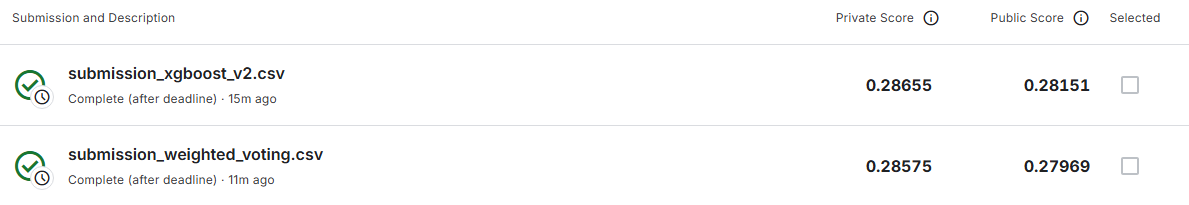